In [1]:
from pathlib import Path
from typing import Union, Optional
import copy
import numpy as np
np.random.seed(42)
import matplotlib.pyplot as pltvenv
from matplotlib import axes
import xarray as xr
import pandas as pd
from spotpy.algorithms import _algorithm
import spotpy
import tqdm
from scipy.stats import wasserstein_distance
import dask.array as da
import datetime 
import os
import matplotlib.pyplot as plt #this works for Meghan using version 3.10.7


In [2]:
from hydrus_setup import HydrusSetup
from MS_CUA import MsCua

In [3]:
#give path to exe file
exe = os.path.join(os.getcwd(), "H1D_CALC.EXE")

#name the folder files will fill
main_level = os.path.normpath(os.path.join(os.getcwd(), os.pardir))

In [4]:
# Identify file names/paths for input data
input_files = [f for f in os.listdir(os.path.join(main_level, '1_Input',))]

weather_csv = [s for s in input_files if "weather" in s.lower()][0]
irgn_csv = [s for s in input_files if "irrigation" in s.lower()][0]
obs_csv = [s for s in input_files if "observation" in s.lower()][0]
vg_csv = [s for s in input_files if "vg" in s.lower()][0]
crop_csv = [s for s in input_files if "crop" in s.lower()][0]
gdd_csv = [s for s in input_files if "gdd" in s.lower()][0]
calib_csv = [f for f in os.listdir(os.path.join(main_level, '1_Input', 'FieldData', 'CalibrationData'))][0]


In [5]:
# Load and clean calib data
calib = pd.read_csv(os.path.join(main_level, '1_Input', 'FieldData',  'CalibrationData', calib_csv))
calib["Date"] = pd.to_datetime(calib["Date"])

# filter calibration data to be contrained by weather data time period (which dictates hydrus output period)
weather_df = pd.read_csv(os.path.join(main_level, '1_Input', weather_csv))
weather_df['Date'] = pd.to_datetime(weather_df['Date'])
calib = calib.loc[(calib['Date'] >= min(weather_df.Date)) & (calib['Date'] <= max(weather_df.Date)), ]

In [6]:
def add_gdds(weatherdata, cropdates):
    weatherdata['gdds']=0
    weatherdata['Year']= "NA"

    for i in range(len(weatherdata)):
        weatherdata['Year'][i] = weatherdata.Date.dt.year[i]

    weatherdata['Year'] = weatherdata['Year'].astype(int)

    weatherdata = weatherdata.merge(cropdates, on= "Year").rename(columns={'Seeding': 'StartDate','Harvest': 'EndDate'})
    weatherdata['StartDate'] = pd.to_datetime(weatherdata['StartDate'])
    weatherdata['EndDate'] = pd.to_datetime(weatherdata['EndDate'])
    weatherdata['Date'] = pd.to_datetime(weatherdata['Date'])

    for i in range(0,len(weatherdata)):
        if (weatherdata['Date'][i] >= weatherdata['StartDate'][i] and weatherdata['Date'][i] <= weatherdata['EndDate'][i] and weatherdata['AvgTemp'][i] > 0):
            weatherdata['gdds'][i] = weatherdata['gdds'][i-1] + weatherdata['AvgTemp'][i-1]
    
    return weatherdata

def partition_et(weatherdata, gddinfo):
    
    fallow_coef = gddinfo.loc[gddinfo['crop'] == 'Fallow']['max.coef']

    weatherdata['t_coef'] = 0
    weatherdata['e_coef'] = 0.22
  
    for i in range(len(weatherdata)):
        crop = weatherdata['Crop'][i]
        max_coef = gddinfo.loc[gddinfo['crop'] == crop]['max.coef']
        
        check1 = (weatherdata['gdds'][i] > (gddinfo.loc[gddinfo['crop'] == crop]['gdd2emergence']).astype(int))& (weatherdata['gdds'][i] <= (gddinfo.loc[gddinfo['crop'] == crop]['gdd2close']).astype(int))
        check1 = all(check1)

        if check1 == True:
            weatherdata['t_coef'][i] = (weatherdata['gdds'][i] - gddinfo.loc[gddinfo['crop'] == crop]['gdd2emergence'])*max_coef/(gddinfo.loc[gddinfo['crop'] == crop]['gdd2close']-gddinfo.loc[gddinfo['crop'] == crop]['gdd2emergence'])

        check2 = (weatherdata['gdds'][i] > (gddinfo.loc[gddinfo['crop'] == crop]['gdd2close']).astype(int))& (weatherdata['gdds'][i] <= (gddinfo.loc[gddinfo['crop'] == crop]['gdd2mature']).astype(int))
        check2 = all(check2)

        if check2 == True:
            weatherdata['t_coef'][i] = max_coef
        
        check3 = (weatherdata['gdds'][i] > (gddinfo.loc[gddinfo['crop'] == crop]['gdd2mature']).astype(int))& (weatherdata['gdds'][i] <= (gddinfo.loc[gddinfo['crop'] == crop]['gdd2harvest']).astype(int))
        check3 = all(check3)

        if check3 == True:
            weatherdata['t_coef'][i] = max_coef-(weatherdata['gdds'][i] - gddinfo.loc[gddinfo['crop'] == crop]['gdd2mature'])/(gddinfo.loc[gddinfo['crop'] == crop]['gdd2harvest']-gddinfo.loc[gddinfo['crop'] == crop]['gdd2mature'])

        check4 = weatherdata['t_coef'][i] <= 0.22
        check4 = bool(check4)

        if check4 == True:
            weatherdata['e_coef'][i] = fallow_coef - weatherdata['t_coef'][i]

        check5 = weatherdata['t_coef'][i] > 0.22
        check5 = bool(check5)
        if check5 == True:
            weatherdata['e_coef'][i] = 0

        weatherdata['pot_t_cm'] = weatherdata['ET_cm']*weatherdata['t_coef']
        weatherdata['pot_e_cm'] = weatherdata['ET_cm']*weatherdata['e_coef']

    return(weatherdata)

def grow_roots_obs(weatherdata, rootobs):
    rootobs['Date'] = pd.to_datetime(rootobs['Date'])
    atmtest= weatherdata
    atmtest['RootDepth'] = 0
    atmtest = atmtest.merge(rootobs, how= 'left', on= 'Date')
    atmtest.loc[np.isnan(atmtest['Depth']) == False, 'RootDepth'] = atmtest.loc[np.isnan(atmtest['Depth']) == False, 'Depth']

    years = list(set(atmtest['Year']))

    for k in range(len(years)):
        
        root_year = atmtest.loc[(atmtest['Year'] == years[k]) & (np.isnan(atmtest['Depth']) == False)]

        rts = {'Growthrate': ["NA"], 'Day1': ["NA"], 'Day2': ["NA"]}
        allroots = pd.DataFrame(rts)

        for i in range(1, len(root_year)):
            growth = root_year.iloc[i]['Depth'] - root_year.iloc[i-1]['Depth']
            time = root_year.iloc[i]['Date'] - root_year.iloc[i-1]['Date']
            time= time.days
            growthrate = growth/time
            day1 = root_year.iloc[i-1]['Date']
            day2 = root_year.iloc[i]['Date']

            minidata = pd.DataFrame({'Growthrate':[growthrate], 'Day1':[day1], 'Day2':[day2]})
            allroots = pd.concat([allroots, minidata], ignore_index=True)

        allroots = allroots[allroots['Growthrate'] != "NA"]
        allroots.loc[allroots['Growthrate'] <  0, 'Growthrate'] = 0

        for i in range(len(allroots)):
            day1 = allroots.iloc[i]['Day1']
            day2 = allroots.iloc[i]['Day2']
            gr = allroots.iloc[i]['Growthrate']

            for j in range(len(atmtest)):
                if (atmtest.iloc[j]['Date'] > day1) & (atmtest.iloc[j]['Date'] < day2):
                    atmtest['RootDepth'][j] = atmtest['RootDepth'][j-1] + gr
    return(atmtest)

def grow_roots_gdd(weatherdata, cropdata):
    atmtest = weatherdata
    atmtest['RootDepth'] = 0

    for i in range(1,len(atmtest)):
        crop = atmtest['Crop'][i]
        max_depth = cropdata.loc[cropdata['crop'] == crop, 'root.depth.max']
        max_depth

        check1 = (atmtest.iloc[i]['AvgTemp'] > 0) & (atmtest.iloc[i]['Date'] > atmtest.iloc[i]['StartDate'])&( atmtest.iloc[i]['RootDepth'] < max_depth)
        check1 = all(check1)
        if check1 == True:
            atmtest['RootDepth'][i] = atmtest['RootDepth'][i-1] + (atmtest['AvgTemp'][i] * 0.0665)

        check1b = (atmtest.iloc[i]['AvgTemp'] < 0) & (atmtest.iloc[i]['Date'] > atmtest.iloc[i]['StartDate'])&( atmtest.iloc[i]['RootDepth'] < max_depth)
        check1b = all(check1b)
        if check1b == True:
            atmtest['RootDepth'][i] = atmtest['RootDepth'][i-1] 

        check2 = (atmtest.iloc[i]['AvgTemp'] > 0) & (atmtest.iloc[i]['Date'] > atmtest.iloc[i]['StartDate'])&( atmtest.iloc[i]['RootDepth'] >= max_depth)
        check2 = all(check2)
        if check2 == True:
            atmtest['RootDepth'][i] = atmtest['RootDepth'][i-1] 

        check3 = (atmtest.iloc[i]['Date'] > atmtest.iloc[i]['EndDate'])
        if check3 == True:
            atmtest['RootDepth'][i] = 0

    return(atmtest)

In [7]:
# load inputs for run_hydrus function
atm = pd.read_csv(os.path.join(main_level, '1_Input', weather_csv))
atm['Date'] = pd.to_datetime(atm['Date'])
days = len(atm['Date']) #save length of days column for later steps
irrigation = pd.read_csv(os.path.join(main_level, '1_Input', irgn_csv))
irrigation['Date'] = pd.to_datetime(irrigation['Date'])
cropdates = pd.read_csv(os.path.join(main_level, '1_Input', crop_csv))
gddinfo = pd.read_csv(os.path.join(main_level, '1_Input', gdd_csv))

atm2 = add_gdds(weatherdata=atm, cropdates=cropdates)
atm3 = partition_et(weatherdata= atm2, gddinfo=gddinfo)
atm4b = grow_roots_gdd(weatherdata= atm3, cropdata=gddinfo)

#merge weather and irrigation and add for a total water input column
allatm = atm4b.join(irrigation.set_index('Date'), on='Date')
allatm.loc[np.isnan(allatm['Irrigation_cm']) == True, 'Irrigation_cm'] = 0
allatm['WaterIn_cm'] = allatm['Precip_cm'] + allatm['Irrigation_cm']

#create new dataframe to manipulate to be exactly what is needed for PHydrus (keeping old version w/ temperature info for now)
atm_hydrus = allatm[['WaterIn_cm', 'pot_e_cm', 'pot_t_cm', 'RootDepth']]

#these are required column names: 'tAtm', 'Prec', 'rSoil', 'rRoot', 'hCritA', 'rB', 'hB', 'hT'
atm_hydrus = atm_hydrus.rename(columns={'pot_e_cm':'rSoil', 'WaterIn_cm':'Prec', 'pot_t_cm': 'rRoot'}) #rename columns that are there
atm_hydrus['tAtm'] = range(1,len(atm2)+1)
atm_hydrus['hCritA']= 1000000 #max allowed surface head, this is hydrus default
atm_hydrus['rB']= 0 #bottom flux, is zero for free drainage boundary condition
atm_hydrus['hB']= 0 #groundwater level, is zero if model is not being run with groundwater
atm_hydrus['hT']= 0 #surface pressure head, zero if model uses free drainage

#rearrange to match format input
atm_hydrus = atm_hydrus[['tAtm', 'Prec', 'rSoil', 'rRoot', 'hCritA', 'rB', 'hB', 'hT']]

#Observation Nodes
obs = pd.read_csv(os.path.join(main_level, '1_Input', obs_csv))
obspts = obs.loc[:, "depth"]
obspts= obspts*-1
obslist = list(obspts)

#Timestep list 
timesteps2 = [0.001, 0.003, 0.005, 0.006, 0.0001, 0.0003, 0.0004, 0.01, 0.00002,
            0.00003, 0.00004, 0.00005, 0.00006, 0.00007, 0.00009, 0.0002, 0.0007, 0.0009,
            0.0055, 0.0065, 0.00015, 0.00055, 0.00095] #actual good time steps

atm_hydrus

C:\Users\x63d979\AppData\Local\Temp\ipykernel_29456\2697420229.py:6: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  weatherdata['Year'][i] = weatherdata.Date.dt.year[i]
C:\Users\x63d979\AppData\Local\Temp\ipykernel_29456\2697420229.py:6: Sett

,tAtm,Prec,rSoil,rRoot,hCritA,rB,hB,hT
0,1,0.0000,0.015646,0.0,1000000,0,0,0
1,2,0.0000,0.007823,0.0,1000000,0,0,0
2,3,0.0000,0.023470,0.0,1000000,0,0,0
3,4,0.0000,0.016764,0.0,1000000,0,0,0
4,5,0.0000,0.007264,0.0,1000000,0,0,0
...,...,...,...,...,...,...,...,...
751,752,0.0000,0.032969,0.0,1000000,0,0,0
752,753,0.0000,0.010058,0.0,1000000,0,0,0
753,754,0.0000,0.034087,0.0,1000000,0,0,0
754,755,0.0663,0.006147,0.0,1000000,0,0,0


In [8]:
# Format vgs to be an array
vgs = pd.read_csv(os.path.join(main_level, '1_Input', vg_csv)).iloc[:, 2:]
vg_len = 17 # 17 for dual perm; 6 for single porosity 
vgs_array = np.array(vgs).reshape(1,len(vgs),vg_len)[0] 
vgs_array

array([[7.9200e-02, 4.4180e-01, 1.5800e-02, 1.4145e+00, 8.1800e+00,
        5.0000e-01, 1.0000e-02, 3.0000e-01, 1.0000e-03, 1.5000e+00,
        1.0000e+02, 5.0000e-01, 2.0000e-01, 1.3000e+00, 4.0000e-01,
        2.0000e+00, 3.0000e-04]])

In [9]:
# testing a single converging run (took about 2 sec)
from main import run_with_timeout
import numpy as np

fallback = np.full((np.array(calib.drop(columns=["Date"])).shape), np.nan)

alldata, hydrus_output = run_with_timeout(
    vgs, calib, atm, atm_hydrus, obs, days, timesteps2,
    fallback=fallback,
    timeout=60  # generous timeout for first test
)

print("Output:\n", hydrus_output)

Process finished, reading result from file
Output:
 [[0.2154]
 [0.2154]
 [0.2155]
 [0.2156]
 [0.2157]
 [0.2158]
 [0.2159]
 [0.2161]
 [0.2162]
 [0.2163]
 [0.2164]
 [0.2165]
 [0.2166]
 [0.2167]
 [0.2168]
 [0.2169]
 [0.2169]
 [0.217 ]
 [0.2171]
 [0.2171]
 [0.2172]
 [0.2172]
 [0.2173]
 [0.2173]
 [0.2174]
 [0.2176]
 [0.2178]
 [0.218 ]
 [0.2183]
 [0.2186]
 [0.2189]
 [0.2192]
 [0.2196]
 [0.22  ]
 [0.2203]
 [0.2206]
 [0.221 ]
 [0.2213]
 [0.2216]
 [0.2219]
 [0.2222]
 [0.2225]
 [0.2227]
 [0.223 ]
 [0.2233]
 [0.2236]
 [0.2239]
 [0.2241]
 [0.2244]
 [0.2245]
 [0.2247]
 [0.2248]
 [0.2249]
 [0.225 ]
 [0.225 ]
 [0.2251]
 [0.2251]
 [0.2251]
 [0.2251]
 [0.2252]
 [0.2263]
 [0.2298]
 [0.2348]
 [0.2401]
 [0.2443]
 [0.2471]
 [0.249 ]
 [0.2503]
 [0.2512]
 [0.2516]
 [0.2518]
 [0.2517]
 [0.2515]
 [0.2513]
 [0.2509]
 [0.2506]
 [0.2503]
 [0.25  ]
 [0.2497]
 [0.2498]
 [0.2508]
 [0.2537]
 [0.2595]
 [0.2668]
 [0.2723]
 [0.2752]
 [0.2764]
 [0.2767]
 [0.2764]
 [0.2759]
 [0.275 ]
 [0.2741]
 [0.2731]
 [0.2721]
 [0.2711

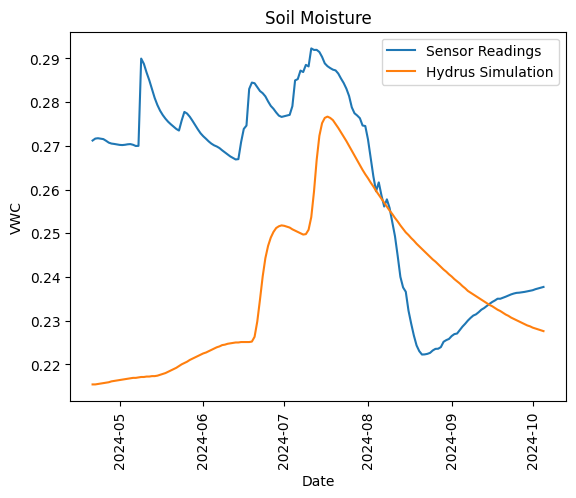

In [10]:
# plot observed and simulated results at observation node

plt.figure()
plt.plot(calib["Date"], calib.iloc[:,1], label='Sensor Readings')
plt.plot(calib["Date"], hydrus_output, label='Hydrus Simulation')
plt.xlabel("Date")
plt.ylabel("VWC")
plt.title("Soil Moisture")
plt.xticks(rotation=90)
plt.legend()
plt.show()

In [11]:
setup = HydrusSetup(calib, atm, atm_hydrus, obs, days, timesteps2)
mscua = MsCua(setup, dbname='vg_calibration', dbformat='memory')


In Memory database initialized...


[[0.0792, 0.4418, 0.0158, 1.4145, 8.18, 0.5, 0.01, 0.3, 0.001, 1.5, 100.0, 0.5, 0.2, 1.3, 0.4, 2.0, 0.0003]]
Process finished, reading result from file


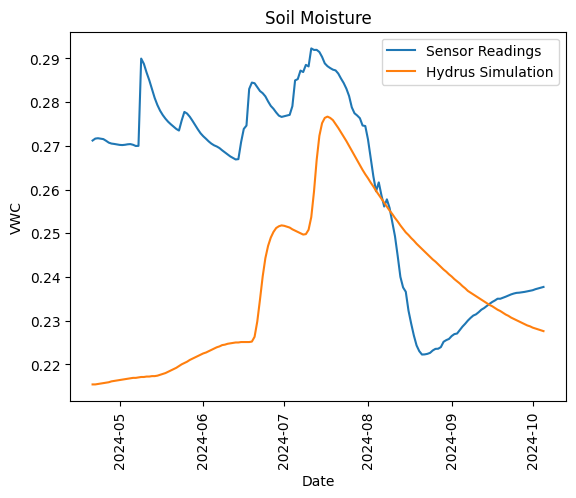

In [12]:
# testing HydrusSetup.simulation()
params = {'thetar': 0.0792,
          'thetas': 0.4418,
          'alpha': 0.0158,
          'n': 1.4145,
          'ksat': 8.18,
          'l': 0.5,
          'thrfr': 0.01,
          'thsfr': 0.3,
          'alphafr':0.001,
          'nfr'	:1.5,
          'ksfr': 100,
          'lfr': 0.5,
          'w': 0.2,
          'beta': 1.3,
          'gamma':	0.4,
          'a' : 2,
          'ka': 0.0003
}
hydrus_output = setup.simulation(params)

# plot
plt.figure()
plt.plot(calib["Date"], calib.iloc[:,1], label='Sensor Readings')
plt.plot(calib["Date"], hydrus_output, label='Hydrus Simulation')
plt.xlabel("Date")
plt.ylabel("VWC")
plt.title("Soil Moisture")
plt.xticks(rotation=90)
plt.legend()
plt.show()

In [13]:
thetar = spotpy.parameter.Uniform(low=0.05, high=0.1)
thetas = spotpy.parameter.Uniform(low=0.35, high=0.5)
alpha = spotpy.parameter.Uniform(low=0.005, high=0.04)
n = spotpy.parameter.Uniform(low=1.1, high=2.0)
ksat = spotpy.parameter.Uniform(low=5.0, high=500)
l = spotpy.parameter.Uniform(low=0.5, high=0.5)
thetar_macro = spotpy.parameter.Uniform(low=0, high=0.1)
thetas_macro = spotpy.parameter.Uniform(low=0.2, high=0.8)
alpha_macro = spotpy.parameter.Uniform(low=0.001, high=0.8)
n_macro = spotpy.parameter.Uniform(low=1.01, high=7)
ksat_macro = spotpy.parameter.Uniform(low=1, high=1000)
l_macro = spotpy.parameter.Uniform(low=0.5, high=0.5)
w = spotpy.parameter.Uniform(low=0.001, high=0.25)
beta = spotpy.parameter.Uniform(low=1, high=20)
gamma = spotpy.parameter.Uniform(low=0.4, high=0.4)
a = spotpy.parameter.Uniform(low=0.1, high=10)
ka = spotpy.parameter.Uniform(low=0.00001, high=10)

In [14]:
setup = HydrusSetup(calib, atm, atm_hydrus, obs, days, timesteps2)
mscua = MsCua(setup, dbname='vg_calibration', dbformat='memory')

In Memory database initialized...


In [15]:
result = mscua.sample(
    reps=10,
    objfunc_thresholds={'nse': -5.0}
)

[Uniform('thetar', [0.05, 0.1]), Uniform('thetas', [0.35, 0.5]), Uniform('alpha', [0.005, 0.04]), Uniform('n', [1.1, 2.0]), Uniform('ksat', [5.0, 500]), Uniform('l', [0.5, 0.5]), Uniform('thetar_macro', [0, 0.1]), Uniform('thetas_macro', [0.2, 0.8]), Uniform('alpha_macro', [0.001, 0.8]), Uniform('n_macro', [1.01, 7]), Uniform('ksat_macro', [1, 1000]), Uniform('l_macro', [0.5, 0.5]), Uniform('w', [0.001, 0.25]), Uniform('beta', [1, 20]), Uniform('gamma', [0.4, 0.4]), Uniform('a', [0.1, 10]), Uniform('ka', [1e-05, 10])]
Sampling 10 repetitions of the thetar parameter...


Sampling 10 repetitions of the thetas parameter...


Sampling 10 repetitions of the alpha parameter...


Sampling 10 repetitions of the n parameter...


Sampling 10 repetitions of the ksat parameter...


...

TIMEOUT OCCURRED
[[0.07909177984352496, 0.4223975245639238, 0.016316276736117467, 1.4856070664394836, 400.3538946695486, 0.5, 0.09718742175029338, 0.7089495885099717, 0.4527456348563098, 1.2237242363498477, 408.9533901451792, 0.5, 0.11610537729476217, 13.259431869558087, 0.4, 6.629607992663567, 7.4813430192759665]]


simulation:  90%|█████████ | 9/10 [04:35<00:30, 30.56s/it]

TIMEOUT OCCURRED
[[0.057853046068560746, 0.48312930207224436, 0.0353835288532658, 1.3054836053068686, 250.46180727073013, 0.5, 0.08023699735374416, 0.49448404678408386, 0.20547097426210273, 3.1077896582022184, 280.37533910648267, 0.5, 0.23583393177936424, 8.518274706549029, 0.4, 4.38442804808943, 8.722945658967456]]


TIMEOUT OCCURRED
Evaluating Objective Function Values...


ValueError: evaluation and simulation data do not have the same length.